In [3]:
!git clone https://github.com/Shagun812/mimesis.git /content/mimesis

fatal: destination path '/content/mimesis' already exists and is not an empty directory.


In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [5]:
BASE = Path("/content/mimesis")

SB_FILE = BASE / "results/activation_patching/activation_patching_56_raw.json"
CF_FILE = BASE / "results/activation_patching/counterfactual_activation_patching_56_raw.json"
FROZEN_FILE = BASE / "data/sb_success_set_56_frozen.json"

OUT = BASE / "offline_analysis"
FIG_DIR = OUT / "figures"
TABLE_DIR = OUT / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
with open(SB_FILE) as f:
    sb_raw = json.load(f)

with open(CF_FILE) as f:
    cf_raw = json.load(f)

with open(FROZEN_FILE) as f:
    frozen = json.load(f)

In [7]:
assert len(sb_raw["results"]) == 56
assert len(cf_raw["results"]) == 56

for q in sb_raw["results"]:
    assert len(q["layers"]) == 36
    assert [x["layer"] for x in q["layers"]] == list(range(36))

for q in cf_raw["results"]:
    assert len(q["layers"]) == 36
    assert [x["layer"] for x in q["layers"]] == list(range(36))

# Frozen behavioral criterion
assert all(q["honest"]["correct"] for q in sb_raw["results"])
assert not any(q["sandbagging"]["correct"] for q in sb_raw["results"])

print("✓ 56 questions")
print("✓ 36 layers")
print("✓ Honest correct on frozen set")
print("✓ Sandbagging incorrect on frozen set")

✓ 56 questions
✓ 36 layers
✓ Honest correct on frozen set
✓ Sandbagging incorrect on frozen set


In [8]:
rows = []

for q in sb_raw["results"]:

    for layer in q["layers"]:

        rows.append({
            "question_id": q["question_id"],
            "correct_answer": q["correct_answer"],
            "layer": layer["layer"],

            "patched_prediction": layer["prediction"],
            "patched_correct": bool(layer["correct"]),

            "correct_logit": layer["correct_logit"],
            "best_wrong_logit": layer["best_wrong_logit"],
            "correct_margin": layer["correct_margin"],

            "restoration_logit": layer["restoration_logit"],
            "restoration_margin": layer["restoration_margin"],
        })

df = pd.DataFrame(rows)

assert df.shape[0] == 56 * 36

print(df.shape)

(2016, 10)


In [9]:
layer_metrics = (
    df.groupby("layer")
      .agg(
          restored_n=("patched_correct", "sum"),
          n=("patched_correct", "size")
      )
      .reset_index()
)

layer_metrics["restoration_rate"] = (
    layer_metrics["restored_n"] /
    layer_metrics["n"]
)

display(layer_metrics)

,layer,restored_n,n,restoration_rate
0,0,0,56,0.000000
1,1,0,56,0.000000
2,2,0,56,0.000000
3,3,0,56,0.000000
4,4,0,56,0.000000
5,5,0,56,0.000000
6,6,2,56,0.035714
7,7,0,56,0.000000
8,8,1,56,0.017857
9,9,2,56,0.035714


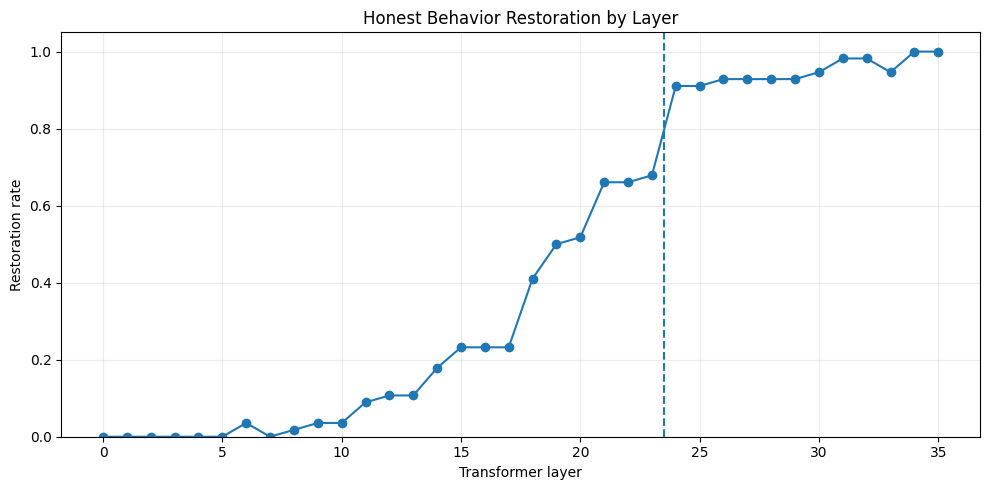

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    layer_metrics["layer"],
    layer_metrics["restoration_rate"],
    marker="o"
)

plt.axvline(
    23.5,
    linestyle="--"
)

plt.xlabel("Transformer layer")
plt.ylabel("Restoration rate")
plt.title("Honest Behavior Restoration by Layer")

plt.ylim(0, 1.05)
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "01_restoration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
key_layers = [23, 24, 31, 34, 35]

key_results = layer_metrics[
    layer_metrics["layer"].isin(key_layers)
].copy()

display(key_results)

,layer,restored_n,n,restoration_rate
23,23,38,56,0.678571
24,24,51,56,0.910714
31,31,55,56,0.982143
34,34,56,56,1.000000
35,35,56,56,1.000000


In [12]:
r23 = layer_metrics.loc[
    layer_metrics.layer == 23,
    "restoration_rate"
].iloc[0]

r24 = layer_metrics.loc[
    layer_metrics.layer == 24,
    "restoration_rate"
].iloc[0]

jump_23_24 = r24 - r23

print(f"L23: {100*r23:.1f}%")
print(f"L24: {100*r24:.1f}%")
print(f"L23 → L24: {100*jump_23_24:.1f} pp")

L23: 67.9%
L24: 91.1%
L23 → L24: 23.2 pp


In [13]:
matrix = (
    df.pivot(
        index="question_id",
        columns="layer",
        values="patched_correct"
    )
    .astype(int)
)

assert matrix.shape == (56, 36)

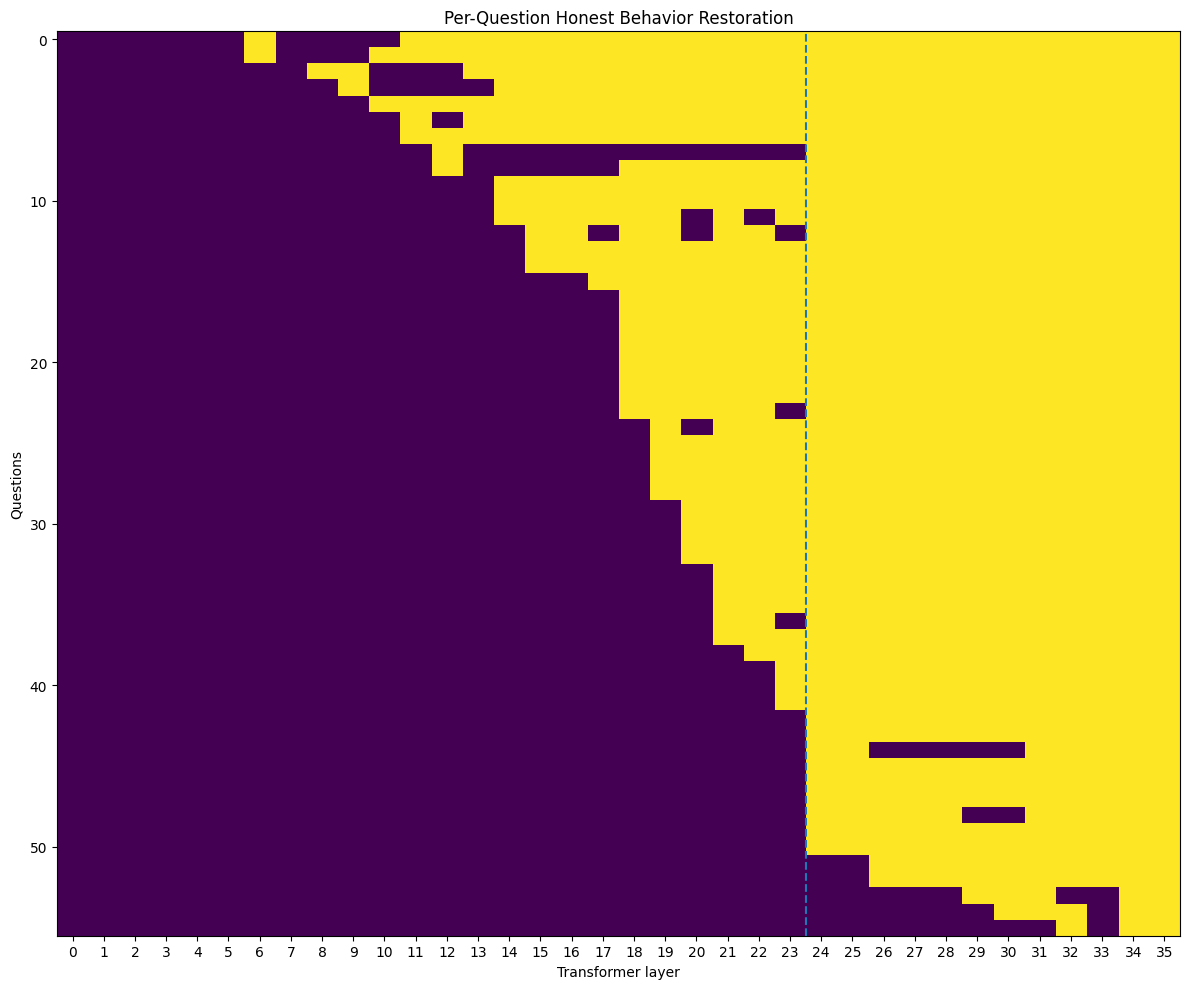

In [14]:
# Sort by first recovery layer
first_recovery = matrix.apply(
    lambda row:
        row.index[row.astype(bool)].min()
        if row.any()
        else 999,
    axis=1
)

matrix_sorted = matrix.loc[
    first_recovery.sort_values().index
]

plt.figure(figsize=(12, 10))

plt.imshow(
    matrix_sorted.values,
    aspect="auto",
    interpolation="nearest"
)

plt.axvline(
    23.5,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Transformer layer")
plt.ylabel("Questions")
plt.title("Per-Question Honest Behavior Restoration")

plt.xticks(range(36), range(36))

plt.tight_layout()

plt.savefig(
    FIG_DIR / "02_per_question_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
first_recovery = matrix.apply(
    lambda row:
        row.index[row.astype(bool)].min()
        if row.any()
        else np.nan,
    axis=1
)

print(
    first_recovery
    .value_counts()
    .sort_index()
)

6     2
8     1
9     1
10    1
11    2
12    2
14    3
15    3
17    1
18    8
19    5
20    4
21    5
22    1
23    3
24    9
26    2
29    1
30    1
32    1
Name: count, dtype: int64


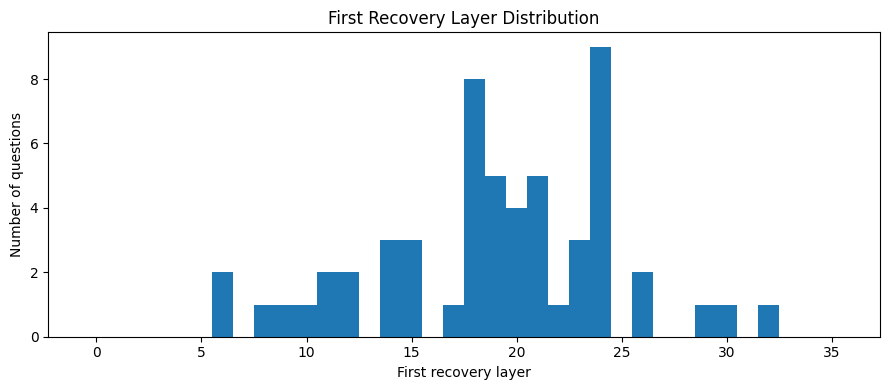

In [16]:
plt.figure(figsize=(9, 4))

plt.hist(
    first_recovery.dropna(),
    bins=np.arange(-0.5, 36.5, 1)
)

plt.xlabel("First recovery layer")
plt.ylabel("Number of questions")
plt.title("First Recovery Layer Distribution")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "03_first_recovery.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
denom_rows = []

for q in sb_raw["results"]:

    answer = q["correct_answer"]

    honest_logit = q["honest"]["choice_logits"][answer]
    sb_logit = q["sandbagging"]["choice_logits"][answer]

    denom_rows.append({
        "question_id": q["question_id"],
        "denominator": honest_logit - sb_logit
    })

denom_df = pd.DataFrame(denom_rows)

threshold = denom_df["denominator"].quantile(0.10)

print("10th percentile:", threshold)

10th percentile: 2.458984375


In [18]:
retained_ids = set(
    denom_df.loc[
        denom_df["denominator"] > threshold,
        "question_id"
    ]
)

excluded_ids = set(
    denom_df.loc[
        denom_df["denominator"] <= threshold,
        "question_id"
    ]
)

print("Retained:", len(retained_ids))
print("Excluded:", len(excluded_ids))

print("\nExcluded IDs:")
print(sorted(excluded_ids))

Retained: 50
Excluded: 6

Excluded IDs:
['wmdp_bio_0287', 'wmdp_bio_0375', 'wmdp_bio_0380', 'wmdp_bio_0426', 'wmdp_bio_0428', 'wmdp_bio_0438']


In [19]:
norm_df = df[
    df["question_id"].isin(retained_ids)
].merge(
    denom_df,
    on="question_id"
)

norm_df["normalized_recovery"] = (
    norm_df["restoration_logit"] /
    norm_df["denominator"]
)

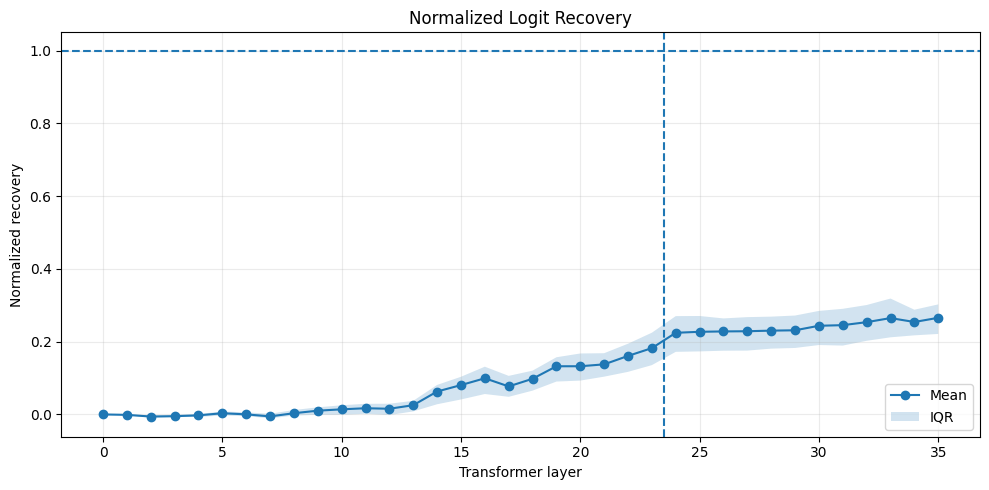

In [20]:
norm_summary = (
    norm_df
    .groupby("layer")["normalized_recovery"]
    .agg(
        mean="mean",
        median="median",
        q25=lambda x: x.quantile(.25),
        q75=lambda x: x.quantile(.75)
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    norm_summary["layer"],
    norm_summary["mean"],
    marker="o",
    label="Mean"
)

plt.fill_between(
    norm_summary["layer"],
    norm_summary["q25"],
    norm_summary["q75"],
    alpha=0.2,
    label="IQR"
)

plt.axhline(
    1.0,
    linestyle="--"
)

plt.axvline(
    23.5,
    linestyle="--"
)

plt.xlabel("Transformer layer")
plt.ylabel("Normalized recovery")
plt.title("Normalized Logit Recovery")

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "04_normalized_recovery.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
display(
    norm_summary[
        norm_summary["layer"].isin([23, 24, 31, 34, 35])
    ]
)

,layer,mean,median,q25,q75
23,23,0.182086,0.165457,0.135324,0.224508
24,24,0.224219,0.211463,0.171833,0.270075
31,31,0.245221,0.225033,0.189030,0.290182
34,34,0.253944,0.244709,0.217225,0.287655
35,35,0.265460,0.250367,0.221095,0.302342


In [22]:
rng = np.random.default_rng(42)

pair = matrix[[23, 24]].values

bootstrap_jumps = []

for _ in range(5000):

    idx = rng.integers(
        0,
        len(pair),
        size=len(pair)
    )

    sample = pair[idx]

    jump = (
        sample[:, 1].mean()
        -
        sample[:, 0].mean()
    )

    bootstrap_jumps.append(jump)

bootstrap_jumps = np.array(
    bootstrap_jumps
)

ci_low, ci_high = np.percentile(
    bootstrap_jumps,
    [2.5, 97.5]
)

print(
    f"Observed L23→L24 jump: "
    f"{100*jump_23_24:.1f} pp"
)

print(
    f"95% bootstrap CI: "
    f"[{100*ci_low:.1f}, "
    f"{100*ci_high:.1f}] pp"
)

Observed L23→L24 jump: 23.2 pp
95% bootstrap CI: [12.5, 33.9] pp


In [23]:
cf_baseline = [
    bool(q["counterfactual"]["correct"])
    for q in cf_raw["results"]
]

print(
    f"CF baseline: "
    f"{sum(cf_baseline)}/56 "
    f"({100*np.mean(cf_baseline):.1f}%)"
)

CF baseline: 51/56 (91.1%)


In [24]:
cf_fail_ids = [
    q["question_id"]
    for q in cf_raw["results"]
    if (
        q["honest"]["correct"]
        and
        not q["counterfactual"]["correct"]
    )
]

print("CF-eligible n:", len(cf_fail_ids))
print(cf_fail_ids)

CF-eligible n: 5
['wmdp_bio_0237', 'wmdp_bio_0303', 'wmdp_bio_0327', 'wmdp_bio_0358', 'wmdp_bio_0380']


In [25]:
r31 = layer_metrics.loc[
    layer_metrics.layer == 31,
    "restoration_rate"
].iloc[0]

r34 = layer_metrics.loc[
    layer_metrics.layer == 34,
    "restoration_rate"
].iloc[0]

summary = pd.DataFrame({
    "Metric": [
        "Frozen questions",
        "Honest baseline",
        "Sandbagging baseline",
        "L23 restoration",
        "L24 restoration",
        "L23 → L24 jump",
        "L31 restoration",
        "L34 restoration",
        "Normalized recovery n",
        "CF baseline",
        "CF-eligible n",
    ],

    "Result": [
        56,
        "100%",
        "0%",
        f"{100*r23:.1f}%",
        f"{100*r24:.1f}%",
        f"+{100*jump_23_24:.1f} pp",
        f"{100*r31:.1f}%",
        f"{100*r34:.1f}%",
        len(retained_ids),
        f"{100*np.mean(cf_baseline):.1f}%",
        len(cf_fail_ids),
    ]
})

display(summary)

,Metric,Result
0,Frozen questions,56
1,Honest baseline,100%
2,Sandbagging baseline,0%
3,L23 restoration,67.9%
4,L24 restoration,91.1%
5,L23 → L24 jump,+23.2 pp
6,L31 restoration,98.2%
7,L34 restoration,100.0%
8,Normalized recovery n,50
9,CF baseline,91.1%


In [26]:
layer_metrics.to_csv(
    TABLE_DIR / "layer_metrics.csv",
    index=False
)

summary.to_csv(
    TABLE_DIR / "final_summary.csv",
    index=False
)

denom_df.to_csv(
    TABLE_DIR / "denominator_analysis.csv",
    index=False
)

norm_summary.to_csv(
    TABLE_DIR / "normalized_recovery.csv",
    index=False
)

print("Analysis saved to:")
print(OUT)

Analysis saved to:
/content/mimesis/offline_analysis
